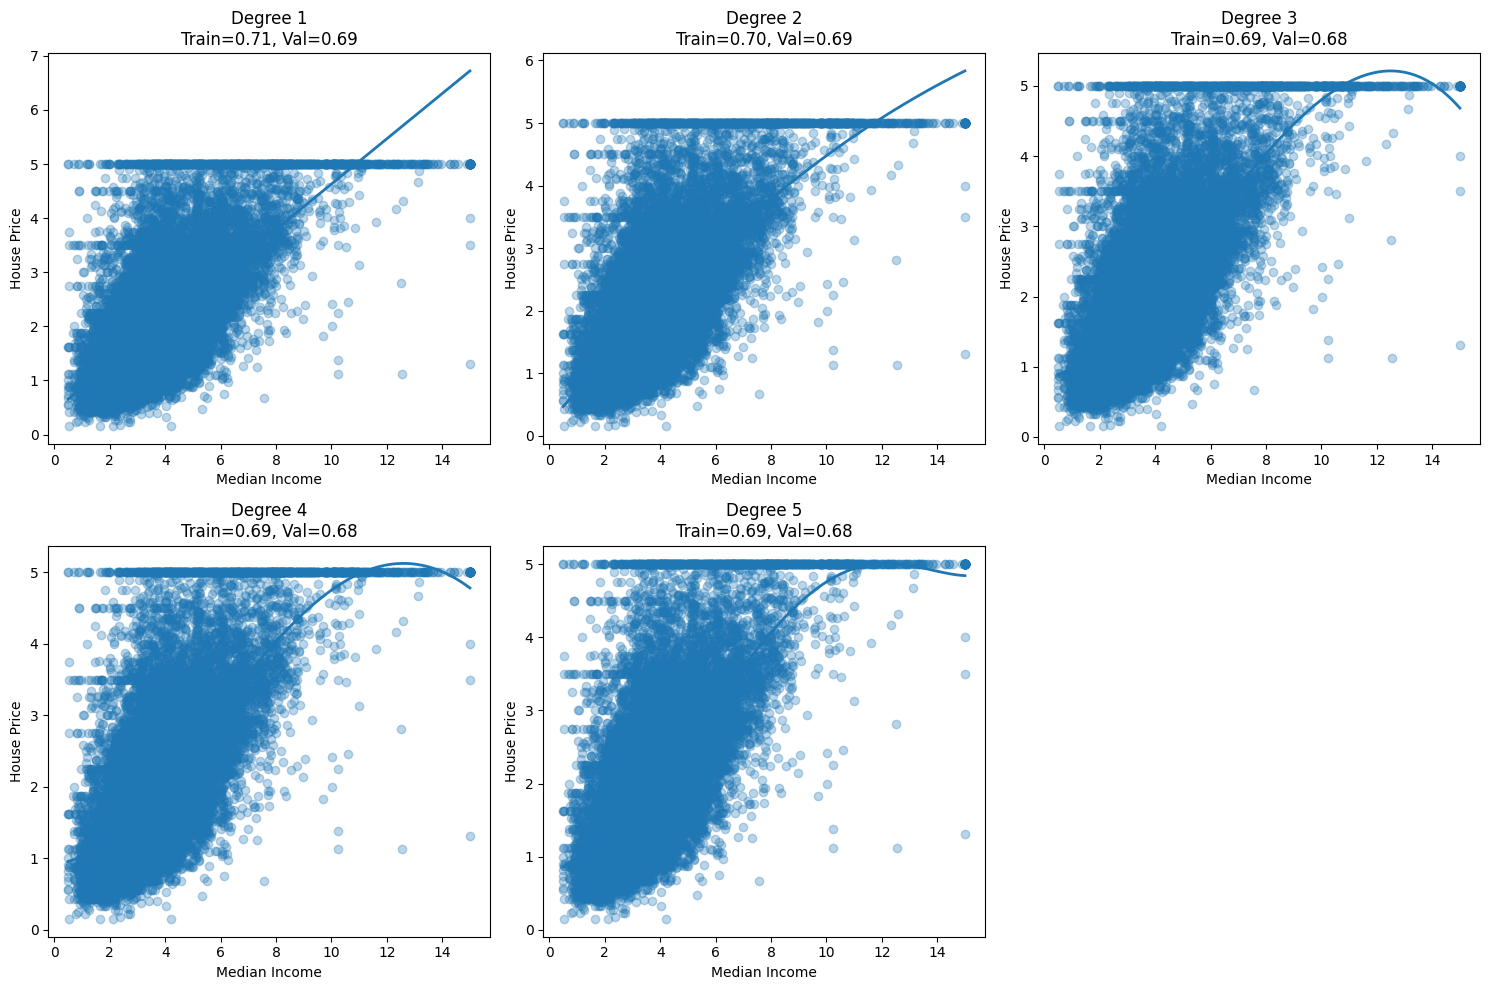

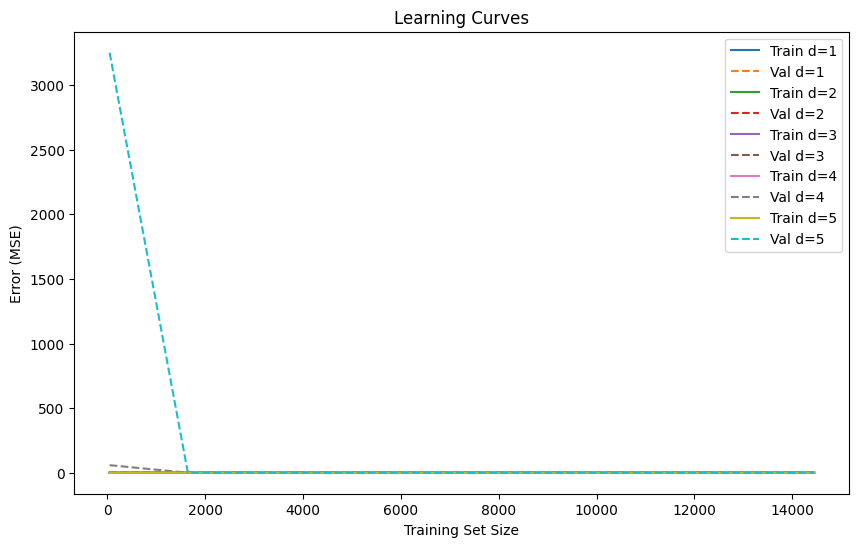

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# -------------------------------
# 1. LOAD PUBLIC DATASET
# -------------------------------
data = fetch_california_housing()

# We take ONLY ONE feature for visualization (MedInc = Median Income)
X = data.data[:, 0].reshape(-1, 1)
y = data.target.reshape(-1, 1)

# -------------------------------
# 2. SPLIT DATA (70% train, 30% validation)
# -------------------------------
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# -------------------------------
# 3. TRAIN MODELS FOR DIFFERENT DEGREES
# -------------------------------
degrees = [1, 2, 3, 4, 5]

plt.figure(figsize=(15, 10))

for i, d in enumerate(degrees, 1):

    poly = PolynomialFeatures(degree=d)
    X_train_poly = poly.fit_transform(X_train)
    X_val_poly = poly.transform(X_val)

    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    # Predictions
    y_train_pred = model.predict(X_train_poly)
    y_val_pred = model.predict(X_val_poly)

    # Errors
    train_error = mean_squared_error(y_train, y_train_pred)
    val_error = mean_squared_error(y_val, y_val_pred)

    # -------------------------------
    # PLOT REGRESSION CURVE
    # -------------------------------
    plt.subplot(2, 3, i)

    plt.scatter(X, y, alpha=0.3)

    X_plot = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
    X_plot_poly = poly.transform(X_plot)
    y_plot = model.predict(X_plot_poly)

    plt.plot(X_plot, y_plot, linewidth=2)

    plt.title(f"Degree {d}\nTrain={train_error:.2f}, Val={val_error:.2f}")
    plt.xlabel("Median Income")
    plt.ylabel("House Price")

plt.tight_layout()
plt.show()

# -------------------------------
# 4. LEARNING CURVES
# -------------------------------
plt.figure(figsize=(10, 6))

for d in degrees:

    poly = PolynomialFeatures(degree=d)

    train_errors = []
    val_errors = []

    sizes = np.linspace(50, len(X_train), 10, dtype=int)

    for size in sizes:
        X_sub = X_train[:size]
        y_sub = y_train[:size]

        X_sub_poly = poly.fit_transform(X_sub)
        X_val_poly = poly.transform(X_val)

        model = LinearRegression()
        model.fit(X_sub_poly, y_sub)

        y_sub_pred = model.predict(X_sub_poly)
        y_val_pred = model.predict(X_val_poly)

        train_errors.append(mean_squared_error(y_sub, y_sub_pred))
        val_errors.append(mean_squared_error(y_val, y_val_pred))

    plt.plot(sizes, train_errors, label=f"Train d={d}")
    plt.plot(sizes, val_errors, linestyle='--', label=f"Val d={d}")

plt.xlabel("Training Set Size")
plt.ylabel("Error (MSE)")
plt.title("Learning Curves")
plt.legend()
plt.show()